<a href="https://colab.research.google.com/github/geoc1234/sourdough/blob/main/notebooks/BakingWithFIPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.0/449.0 kB 7.9 MB/s eta 0:00:00


In [ ]:
from fipy import (CellVariable, Grid1D, TransientTerm, ImplicitDiffusionTerm, DiffusionTerm, Viewer,
    ExplicitDiffusionTerm, GeneralSolver, PowerLawConvectionTerm, ImplicitSourceTerm, FaceVariable,
    ConvectionTerm, Variable)
from fipy.tools import numerix as nx
from fipy.meshes.sphericalUniformGrid1D import SphericalUniformGrid1D
from fipy.meshes.grid1D import Grid1D
import time
import matplotlib.pyplot as plt
import pickle
from tqdm.notebook import tqdm

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: Grid1D has been deprecated use NonUniformGrid1D instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


The following code block contains all the user adjustable parameters

In [ ]:
# Should the simulation start from another
load_results = False
file_name_read = 'drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation.pkl'

# Should the results of this run be saved?
save_results = True
file_name_write = 'drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation.pkl'

# Should the results be plotted against a comparison set?
compare_results = False
file_name_compare = 'drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation.pkl'

# Define Environmental Parameters
T_initial = (74 + 460)/1.8        # Initial temperature (K)
P_total_initial = 101325.0        # assuming constant total pressure of 1 atm (in Pascals)
P_total = P_total_initial         # P_total is assumed constant for now, but this may change
T_oven_i = (450 + 460)/1.8         # Oven temperature (K)
Toramp = 0.0
Tomax = (450 + 460)/1.8
volumeWallOven = 18.0*18.0*24.0*(2.54**3)/1.0e6 # m3
volumeDutchOven = nx.pi*25.0*8.0*(2.54**3)/1.0e6 # m3
volumeOven = volumeWallOven     # m3
#rhoVaporOven_initial = 0         # kg/m3

print(f'Initial Temperature = ', T_initial*1.8 - 460,
      ' F, P_total = ', P_total,' Pa')

# Define Constants and Simulation Parameters:
rhoWater = 1000.0                 # density of water, assumed fixed (kg/m^3)
massFlour = 0.08                  # kg of dry flour
hydration = 0.70                  # water content in bakers units
kw = 1.0e-2                       # convective Mass Transfer mol/m2 sec
k_thermal = 0.309                 # Thermal conductivity of the solid (W/m·K)
h = 10.0                          # Heat transfer coefficient (W/m^2·K)
kg = 2.5e-12                      # permeability of the dough m2
visg = 1.8e-5                     # dynamic viscosity of vapor phase Pa.s
LatentHeat = 2260000.0            # J/kg water
#starting_step = 0                # starting step of simulation
bakeTime = 5                      # baking time in integer minutes
tau = 0.4                         # seconds needed to reach vapor/water equilibrium in the control volume
dt = 0.5                          # simulation time step
dr = 0.002                        # Grid spacing (2 mm)
verbosity = 0                     # verbosity level of code @ runtime

DG = 5.0e-5 * ((1 - 1.11*0.2)*0.5)**(4/3)
print(f'Magnitude of Darcy Flow/Diffusive Flow: ',(kg/visg)*1e5/DG,', but we also ignore volume expansion andn assume consant pressure')

print(f'Mass Flour = ', massFlour,' kg, Hydration = ', hydration,', Bake Time = ',bakeTime,' min')

Initial Temperature =  74.0  F, P_total =  101325.0  Pa
Magnitude of Darcy Flow/Diffusive Flow:  978.2083465920647 , but we also ignore volume expansion andn assume consant pressure
Mass Flour =  0.08  kg, Hydration =  0.7 , Bake Time =  5  min


The following code block executes the simulation

In [ ]:
# Define Derived Constants:
massDough = massFlour*(1+hydration)     # mass of flour + mass of water
volumeDough = 3*massFlour/1000          # volume of the dough (m3)
radiusDough = (3*volumeDough/(4*nx.pi))**(1/3) # m
densityDough = massDough/volumeDough    # density of the dough (kg/m3)
phi_initial = (1.5 + hydration)/3       # fraction of dough volume occupied by gas or water
Wsat_initial= hydration/3/phi_initial   # fraction of phi*volume occupied by liquid water
rhoWsatphi_i = rhoWater*Wsat_initial*phi_initial
rhoSolid_i = massFlour/(volumeDough*(1-phi_initial))
massDoughWater_i = massFlour*hydration
# Define Helper Functions
def Moisture(rhoWsatphi,rhosolid,phi):
  # moisture fraction of dough on a dry basis
  return rhoWsatphi/(rhosolid*(1-phi))

def Activity(moisture,temperature):
  act = 1 +((100*moisture)*nx.exp(0.0056*temperature - 5.5))**(-1/0.38)
  return 1.0/act

def Psat_water(temperature):
  # water vapor pressure, Pa
  return 1000*0.6*nx.exp(17.625*(temperature-273)/(temperature-30))

def Fugacity(temperature, rhoWsatphi,rhos,phi):
  #vapor pressure of water in equilibrium with wet dough, Pa
  return Psat_water(temperature)*Activity(Moisture(rhoWsatphi,rhos,phi),temperature)

def RhoVap_equilibrium(temperature,rhoWsatphi,rhos,phi):
  #equilibrium density of water vapor, kg/m3
  fug = Fugacity(temperature,rhoWsatphi,rhos,phi)
  return 0.018*fug/8.314/temperature

def equilibrate(temperature, rhoWsatphi, rhos, rhoVsatphi, rhowater,phi):
  #returns the mass of water that must evaporate (per volume of dough) to bring systemm to equilibrium
    NwaterVapor = RhoVap_equilibrium(temperature,rhoWsatphi,rhos,phi) #equilibrium mass density
    evaporation = NwaterVapor*phi*(1-rhoWsatphi/(rhowater*phi)) - rhoVsatphi #kg/m3 water to evaporate
    return evaporation

def DiffWater(rhoWsatphi,rhos,phi):
  moist = Moisture(rhoWsatphi,rhos,phi)
  return (1e-9)*nx.exp(2*moist - 2.8)

def P_Total(rhowater,rhowsatphi,fugacity,rhovsatphi,phi,temperature):
  P_tot = (1-rhowsatphi/(rhowater*phi))*(fugacity/rhovsatphi)*(fugacity*0.018/(8.314*temperature)*phi)
  return P_tot

def rho_eff(phi, rhoSolid, rhoWsatphi):
  return (1-phi)*rhoSolid + rhoWsatphi

def Cp_eff(phi, rhoWsatphi):
  CpSolid = 3000.0
  CpWater = 4180.0
  CpGas = 1000.0
  return CpSolid*(1-phi) + CpWater*rhoWsatphi/rhoWater #+ CpGas*phi*(1-Wsat)

def RhoCpe():
  CpSolid = 3000.0
  CpWater = 4180.0
  CpGas = 1000.0
  return rhoSolid_i*CpSolid*(1-phi) + CpWater*rhoWsatphi + CpGas*rhoVsatphi

# Define Parameters & Initial Conditions dependent on the helper functions.  These
# are not updated during the simulation
massOvenWater_i =  0.5*Psat_water((74.0+460.0)/1.8)*volumeOven*0.018/(8.314*(74.0+460.0)/1.8)
fug_initial = Fugacity(T_initial,rhoWsatphi_i,rhoSolid_i,phi_initial)
rhoVapor_initial = RhoVap_equilibrium(T_initial,rhoWsatphi_i,rhoSolid_i,phi_initial)
P_CO2_i = P_total_initial - fug_initial
rhoC_initial = P_CO2_i*0.044/(8.314*T_initial)
Vsat_initial = (1-Wsat_initial)*fug_initial/P_total_initial
Csat_initial = (1-Wsat_initial)*P_CO2_i/P_total_initial
rhoVsatphi_i = rhoVapor_initial*Vsat_initial*phi_initial
rhoCsatphi_i = rhoC_initial*Csat_initial*phi_initial
Cpeff_i = Cp_eff(phi_initial,Wsat_initial)
rhoeff_i = rho_eff(phi_initial,rhoSolid_i,rhoWsatphi_i)
# Define the mesh
nr_grid = int(radiusDough/dr) # Number of grid points in the 1D domain
mesh = SphericalUniformGrid1D(nx=nr_grid, dx=dr)

print(f'Radius = ',radiusDough, 'Mesh Resolution = ', dr,' Number of Points = ', nr_grid)

# Declare FIPY Cell Variables to track that can be assigned to cell volumes:
# (these are updated during the simulation and define the current
# state of the simulation
Pressure = CellVariable(mesh=mesh, name='pressure', value=P_total_initial)
phi = CellVariable(name="porosity", mesh=mesh, value=phi_initial)
T = CellVariable(name="Temp(K)", mesh=mesh, value=T_initial,hasOld=True)
Wsat = CellVariable(name='Water Sat', mesh=mesh, value=Wsat_initial,hasOld=True)
rhoWsatphi = CellVariable(name='rhoWsatphi', mesh=mesh, value=rhoWsatphi_i,hasOld=True)
rhoVsatphi = CellVariable(name='rhoVsatphi', mesh=mesh, value=rhoVsatphi_i,hasOld=True)
rhoCsatphi = CellVariable(name='rhoCsatphi', mesh=mesh, value=rhoCsatphi_i,hasOld=True)
rhoCpe= RhoCpe()
rhoCpT = CellVariable(name="rhoCpT", mesh=mesh, value=rhoCpe*T_initial,hasOld=True)

# Define the state parameters that are not derived from instantaneous values of Cell Variables. These
# must be saved!
T_oven = Variable(name="Oven Temp(K)", value=T_oven_i)
timepoint = Variable()
#rhoVaporOven = Variable(name="Oven Vapor Pressure",
#  value=(massDoughWater_i - (rhoWsatphi + rhoVsatphi).cellVolumeAverage()*volumeDough)/volumeOven + massOvenWater_i/volumeOven)rhoVaporOven = Variable(name="Oven Vapor Pressure",
rhoVaporOven = (massDoughWater_i - (rhoWsatphi + rhoVsatphi).cellVolumeAverage()*volumeDough)/volumeOven + massOvenWater_i/volumeOven
timepoint.setValue(0.0)
T_oven_t = []
timepoints_t = []
rhoVaporOven_t = []
T_core = []
T_mid = []
T_R = []
ev=[]
RHO_t=[]
BrowningIndex = []
browning = 0.0
if load_results == True:
  with open(file_name_read, 'rb') as f:
    loaded_simulation_state = pickle.load(f)
    T = loaded_simulation_state['T']
    phi = loaded_simulation_state['phi']
    rhoVsatphi = loaded_simulation_state['rhoVsatphi']
    rhoWsatphi = loaded_simulation_state['rhoWsatphi']
    rhoCsatphi = loaded_simulation_state['rhoCsatphi']
    Wsat = loaded_simulation_state['Wsat']
    rhoCpT = loaded_simulation_state['rhoCpT']
    starting_step = loaded_simulation_state['step'] + 1
    T_oven_t = loaded_simulation_state['T_oven']
    timelapse = loaded_simulation_state['timelapse']
    timepoints_t = loaded_simulation_state['timepoints_t']
    BrowningIndex = loaded_simulation_state['BrowningIndex']
    RHO_t = loaded_simulation_state['RH_oven_t']
    rhoVaporOven_t = loaded_simulation_state['rhoVaporOven_t']
    T_core = loaded_simulation_state['T_core']
    T_mid = loaded_simulation_state['T_mid']
    T_R = loaded_simulation_state['T_R']
    ev = loaded_simulation_state['ev']
    browning = BrowningIndex[-1]
    print(f'Simulation state loaded from {file_name_read}')
else:
  starting_step = 0
  T_oven.setValue(T_oven_i)
  T_oven_t.append(T_oven)
  timepoint.setValue(0.0)
  timepoints_t.append(timepoint)
  T_core.append(T[1].value.copy()*1.8 - 460)
  T_mid.append(T[9].value.copy()*1.8 - 460)
  T_R.append(T[18].value.copy()*1.8 - 460)
  ev.append(0.0)
  BrowningIndex.append(0)
  Browning = BrowningIndex[-1]
  rhoVaporOven_t.append(rhoVaporOven)
  RHO_t.append(rhoVaporOven/(Psat_water(T_oven)*0.018/(8.314*T_oven)))
  timelapse = 0.0

print(f'loaded starting step = ',starting_step)
print(f'loaded T_oven = ',T_oven)

if compare_results == True:
  with open(file_name_compare, 'rb') as f:
    loaded_simulation_state_compare = pickle.load(f)
    T_compare = loaded_simulation_state_compare['T']
    phi_compare = loaded_simulation_state_compare['phi']
    rhoVsatphi_compare = loaded_simulation_state_compare['rhoVsatphi']
    rhoWsatphi_compare = loaded_simulation_state_compare['rhoWsatphi']
    rhoCsatphi_compare = loaded_simulation_state_compare['rhoCsatphi']
    Wsat_compare = loaded_simulation_state_compare['Wsat']
    rhoCpT_compare = loaded_simulation_state_compare['rhoCpT']
    timepoints_compare = loaded_simulation_state_compare['timepoints']
    timelapse_compare = loaded_simulation_state_compare['timelapse']
    starting_step_compare = loaded_simulation_state_compare['step']
    BrowningIndex_compare = loaded_simulation_state_compare['BrowningIndex']
    RHO_compare = loaded_simulation_state_compare['RH_oven']
    T_core_compare = loaded_simulation_state_compare['T_core']
    T_mid_compare = loaded_simulation_state_compare['T_mid']
    T_R_compare = loaded_simulation_state_compare['T_R']
    ev_compare = loaded_simulation_state_compare['ev']
    T_oven_compare = loaded_simulation_state_compare['T_oven']
    print(f'Simulation state loaded from {file_name_compare}')


# Define Variables dependent on the values of Cell Variables - these state parameters are derived and need not be saved
rhoeff = rho_eff(phi,rhoSolid_i,rhoWsatphi)
Cpeff = Cp_eff(phi_initial,Wsat_initial)
rhoCp = rhoeff*Cpeff
DiffusivityWater = FaceVariable(mesh=mesh, rank=0)
DiffusivityGas   = FaceVariable(mesh=mesh, rank=0)
DiffusivityWater.setValue(DiffWater(rhoWsatphi, rhoSolid_i, phi).arithmeticFaceValue())  #3.0e-8 #m2/sec
DiffusivityGas.setValue(5.0e-5 * (((1 - 1.11*Wsat)*phi)**(4/3)).arithmeticFaceValue())
#DiffusivityWater = DiffWater(rhoWsatphi, rhoSolid_i, phi)  #3.0e-8 #m2/sec
#DiffusivityGas   = 5.0e-5 * ((1 - 1.11*Wsat)*phi)**(4/3) #m2/sec
Wsat = rhoWsatphi/(rhoWater*phi)
k_evap = 0.018*phi*(1-Wsat)/(8.314*T)/P_total #kg/mol.sec
evap = (k_evap*(Fugacity(T,rhoWsatphi,rhoSolid_i,phi)**2) - rhoVsatphi)/tau
evap0 = k_evap*Fugacity(T,rhoWsatphi,rhoSolid_i,phi)**2/tau
LatentHeat = (2260000.0 - 2500000.0)/(100.0)*(T - 273.0) + 2500000.0
rhoCpT.setValue(rhoCp*T_initial)
# Define the Boundary Conditions (Robins Boundary conditions):

def cellDistanceVectors(mesh):
  MA = nx.MA # masked array
  tmp = MA.repeat(mesh._faceCenters[..., nx.NewAxis,:], 2, 1) # repeating faceCenters twice along first axis
  cellToFaceDistanceVectors = tmp - nx.take(mesh._cellCenters, mesh.faceCellIDs, axis=1) # select cellCenters for facecellID indices along first axis
  tmp = nx.take(mesh._cellCenters, mesh.faceCellIDs, axis=1)
  tmp = tmp[..., 1,:] - tmp[..., 0,:]
  return MA.filled(MA.where(MA.getmaskarray(tmp), cellToFaceDistanceVectors[:, 0], tmp))

mask = mesh.facesRight
dPf = FaceVariable(mesh = mesh, value = mesh._faceToCellDistanceRatio * cellDistanceVectors(mesh) )
#dPf = FaceVariable(mesh = mesh, value = mesh._faceToCellDistanceRatio * mesh.cellDistanceVectors)
n = mesh.faceNormals
a = FaceVariable(mesh=mesh, value=h*n, rank=1)
b = FaceVariable(mesh=mesh, value=k_thermal, rank=0)
g = FaceVariable(mesh=mesh, value=h*T_oven, rank=0)
#wa = FaceVariable(mesh=mesh, value=kw*n, rank=1)
#wb = FaceVariable(mesh=mesh, value=DiffusivityWater, rank=0)
#wb = FaceVariable(mesh=mesh, value=DiffusivityWater.arithmeticFaceValue(), rank=0)
#wg = FaceVariable(mesh=mesh, value=kw*rhoVaporOven, rank=0)
va = FaceVariable(mesh=mesh, value=kw*n, rank=1)
#vb = FaceVariable(mesh=mesh, value=DiffusivityGas.arithmeticFaceValue(), rank=0)
vb = FaceVariable(mesh=mesh, value=DiffusivityGas, rank=0)
vg = FaceVariable(mesh=mesh, value=kw*rhoVaporOven, rank=0)
ca = FaceVariable(mesh=mesh, value=kw*n, rank=1)
cb = FaceVariable(mesh=mesh, value=DiffusivityGas, rank=0)
#cb = FaceVariable(mesh=mesh, value=DiffusivityGas.arithmeticFaceValue(), rank=0)
cg = FaceVariable(mesh=mesh, value=kw*0, rank=0)
'''
RobinCoeff_c = mask * DiffusivityGas.arithmeticFaceValue() * n / (dPf.dot(ca) + cb)
RobinCoeff_v = mask * DiffusivityGas.arithmeticFaceValue() * n / (dPf.dot(va) + vb)
RobinCoeff_w = mask * DiffusivityWater.arithmeticFaceValue() * n / (dPf.dot(wa) + wb)
RobinCoeff_T = mask * k_thermal * n / (dPf.dot(a) + b)
'''
RobinCoeff_c = mask * DiffusivityGas * n / (dPf.dot(ca) + cb)
RobinCoeff_v = mask * DiffusivityGas * n / (dPf.dot(va) + vb)
#RobinCoeff_w = mask * DiffusivityWater * n / (dPf.dot(wa) + wb)
RobinCoeff_T = mask * k_thermal * n / (dPf.dot(a) + b)

# dt = 0.9*(dr**2)/(2*(k_thermal/rhoCp.cellVolumeAverage()))
nsteps = int(bakeTime*60/dt)
nsweeps = 200

'''
The pressure in each cell starts at 1 atm.  It is comprised of air, water vapor, and CO2.
upon heating, the pressure increases due to water evaporation, but decreases due to volume expansion. In addition,
the thermal energy balance assumes constant pressure. The largest driver of volume expansion is the evaporation, which
will be greatest initially at the surface of the dough.  That pressure spike will compress the water vapor in the
interior of the dough, as well as expand the volume of the dough. Ignoring the volume expansion the bread will,
at least partially, offset the dropping of Darcy flow (convective flux) of the vapor from the simulation.
'''

#P_total = (1-Wsat)*fug_initial/rhoVsatphi*phi*(fug_initial*0.018/(8.314*T))
#print(f'P_Total function test = ',P_total)
#Pressure.setValue(P_total)
#pb = FaceVariable(mesh=mesh, value=P_total.faceGrad(), rank=1)

#print(f'gradP = ',pb)
#conv_gas = kg/visg*pb*n #m2/Pa.s
#conv_gas = kg/visg #m2/Pa.s
#convCoeff = conv_gas*pb
#print(f'conv_gas = ',conv_gas)

term_v = FaceVariable(mesh=mesh, value =((1-Wsat)*phi).arithmeticFaceValue(), rank = 0)

eq_T = TransientTerm(var = T, coeff = rhoCp) == DiffusionTerm(coeff=k_thermal, var = T) + (RobinCoeff_T * g).divergence - \
      ImplicitSourceTerm(coeff=(RobinCoeff_T * a.dot(n)).divergence, var = T) - \
      LatentHeat*evap

'''
eq_rhoWsatphi = TransientTerm(var = rhoWsatphi) == DiffusionTerm(var=rhoWsatphi, coeff=DiffusivityWater * ~mask) + \
  (RobinCoeff_w * wg).divergence - ImplicitSourceTerm(coeff=(RobinCoeff_w * wa.dot(n)).divergence, var=rhoWsatphi) -\
  evap
'''

eq_rhoWsatphi = TransientTerm(var = rhoWsatphi) == DiffusionTerm(var=rhoWsatphi, coeff=DiffusivityWater * ~mask) - \
  evap

eq_rhoVsatphi = TransientTerm(var= rhoVsatphi) == DiffusionTerm(var=rhoVsatphi, coeff=DiffusivityGas * ~mask ) +\
  (RobinCoeff_v * vg * term_v).divergence - ImplicitSourceTerm(coeff=(RobinCoeff_v * va.dot(n)).divergence, var=rhoVsatphi) +\
  evap0 - ImplicitSourceTerm(coeff=1/tau, var=rhoVsatphi)

eq_rhoCsatphi = TransientTerm(var= rhoCsatphi) == DiffusionTerm(var=rhoCsatphi, coeff=DiffusivityGas * ~mask)+ \
    (RobinCoeff_c * cg).divergence - ImplicitSourceTerm(coeff=(RobinCoeff_c * ca.dot(n)).divergence, var=rhoCsatphi)

 #eq_rhoVsatphi = TransientTerm(var= rhoVsatphi) == (DiffusionTerm(var=rhoVsatphi, coeff=DiffusivityGas) +\
 # ConvectionTerm(coeff =-convCoeff, var = rhoVsatphi)) +\
 # (RobinCoeff_v * vg).divergence - ImplicitSourceTerm(coeff=(RobinCoeff_v * va.dot(n)).divergence, var=rhoVsatphi) +\
 # evap0 - ImplicitSourceTerm(coeff=1/tau, var=rhoVsatphi)

#eq_rhoCsatphi = TransientTerm(var= rhoCsatphi) == (DiffusionTerm(var=rhoCsatphi, coeff=DiffusivityGas)+ \
#    ConvectionTerm(coeff=-convCoeff, var=rhoCsatphi)) +\

eq_coupled = eq_T & eq_rhoWsatphi & eq_rhoVsatphi & eq_rhoCsatphi

# solve the equations:
rhoVaporOvenSaturation = Psat_water(T_oven)*0.018/(8.314*T_oven)
print(f'time step = ',dt,'sec, total time = ', nsteps*dt,'sec, ', 'nsteps = ', nsteps )
loopFlag = True
for step in tqdm(range(starting_step, starting_step + nsteps), desc="Simulation Progress"):
  if loopFlag == False:
    break
  timelapse = step*dt
  timepoints_t.append(timelapse)
  T.updateOld()
  rhoVsatphi.updateOld()
  rhoWsatphi.updateOld()
  rhoCsatphi.updateOld()
  '''Troubleshooting Printout
  print(f'timelapse = ',timelapse)
  print(f'RobinCoeffv', RobinCoeff_v * vg * term_v)
  vg.setValue(kw*rhoVaporOven)
  print(f'vg = ',vg)
  print(f'evap0 = ', evap0)
  print(f'evap = ',evap)
  print(f'T_oven = ', T_oven_t[-1])
  print(f'rhoVaporOven_t = ', rhoVaporOven_t[-1])
  print(f'rhoVaporOven ', rhoVaporOven)
  print(f'RHO = ', RHO_t[-1])
  '''
  for sweep in range (nsweeps):
    tol = eq_coupled.sweep(dt=dt)
    if tol < 1e-4:
      break
    elif (tol > 1e-4) & (sweep > nsweeps - 1):
      print(f'convergence not achieved at time = ', timelapse, ' after ', sweep,' sweeps')
      loopFlag = False
      break
  rhoVaporOvenSaturation = Psat_water(T_oven)*0.018/(8.314*T_oven)
  #rhoVaporOven.setValue((massDoughWater_i - (rhoWsatphi + rhoVsatphi).cellVolumeAverage()*volumeDough)/volumeOven + massOvenWater_i/volumeOven)
  rhoVaporOven = (massDoughWater_i - (rhoWsatphi + rhoVsatphi).cellVolumeAverage()*volumeDough)/volumeOven + massOvenWater_i/volumeOven
  RH_oven = rhoVaporOven/rhoVaporOvenSaturation
  RHO_t.append(RH_oven)
  rhoVaporOven_t.append(rhoVaporOven)
  #T_oven.setValue(nx.minimum(T_oven + Toramp*dt, Tomax))
  T_oven_t.append(T_oven)
  ev.append(evap[18].value.copy())
  T_core.append(T[1].value.copy()*1.8 - 460)
  T_mid.append(T[9].value.copy()*1.8 - 460)
  T_R.append(T[18].value.copy()*1.8 - 460)
  k_browning = 42000.0*nx.exp(-64151/(8.324*T[18].value.copy()))
  browning = 52.0 - (52.0 - browning)*nx.exp(-k_browning*dt)
  BrowningIndex.append(browning)
 # if step % 100 == 0: print(f'Lsatent Heat: ', LatentHeat)

if save_results == True:
  import os
  # Extract the directory path from the file name
  save_directory = os.path.dirname(file_name_write)
  # Create the directory if it doesn't exist
  os.makedirs(save_directory, exist_ok=True)

  # Data to be pickled
  simulation_state = {
    'step': step,
    'timelapse': timelapse,
    'timepoints_t': timepoints_t,
    'T': T,
    'rhoVsatphi': rhoVsatphi,
    'rhoWsatphi': rhoWsatphi,
    'rhoCsatphi': rhoCsatphi,
    'rhoCpT': rhoCpT,
    'phi': phi,
    'Wsat': Wsat,
    'BrowningIndex': BrowningIndex,
    'T_core': T_core,
    'T_mid': T_mid,
    'T_R': T_R,
    'RH_oven_t': RHO_t,
    'rhoVaporOven_t': rhoVaporOven_t,
    'T_oven': T_oven_t,
    'ev': ev,
  }

  # Pickle the simulation state
  with open(file_name_write, 'wb') as f:
    pickle.dump(simulation_state, f)

  print(f'Simulation state pickled to {file_name_write}')

viewerT = Viewer(vars=(T))
viewerW = Viewer(vars=(rhoWsatphi))
viewerV = Viewer(vars=(rhoVsatphi))
viewerC = Viewer(vars=(rhoCsatphi))
viewerD = Viewer(vars=(Wsat))
viewerT.plot()
viewerW.plot()
viewerV.plot()
viewerC.plot()
plt.show()

if(compare_results == False):
  plt.plot(timepoints_t, T_core, label='Core')
  plt.plot(timepoints_t, T_mid, label='Midway')
  plt.plot(timepoints_t, T_R, label='Crust')
  plt.axhline(y=212, color='r', linestyle='--')
  plt.xlabel("Time")
  plt.ylabel("Temp Value")
  plt.title("Temp Evolution vs Depth")
  plt.legend()
  plt.show()
  plt.plot(timepoints_t, ev)
  plt.xlabel("Time")
  plt.ylabel("Evap Value")
  plt.title("Evap Evolution over Time")
  plt.show()
  plt.plot(timepoints_t, RHO_t)
  plt.xlabel("Time")
  plt.ylabel("RH ")
  plt.title("Evolution of RH over Time")
  plt.show()
  plt.plot(timepoints_t, BrowningIndex)
  plt.xlabel("Time")
  plt.ylabel("Browning ")
  plt.title("Evolution of color over Time")
  plt.show()
  plt.plot(timepoints_t, T_oven_t)
  plt.xlabel("Time")
  plt.ylabel("Oven Temp K")
  plt.title("Evolution of Oven Temp over Time")
  plt.show()
else:
  plt.plot(timepoints_t, T_core, label='Core')
  plt.plot(timepoints_compare, T_core_compare, label='Core_compare')
  plt.plot(timepoints_t, T_mid, label='Mid')
  plt.plot(timepoints_compare, T_mid_compare, label='Mid_compare')
  plt.plot(timepoints_t, T_R, label='R')
  plt.plot(timepoints_compare, T_R_compare, label='R_compare')
  plt.xlabel("Time")
  plt.ylabel("Temp Value")
  plt.title("Temp Evolution over Time")
  plt.legend()
  plt.show()
  plt.plot(timepoints_t, RHO)
  plt.plot(timepoints_compare, RHO_compare)
  plt.xlabel("Time")
  plt.ylabel("RH ")
  plt.title("Evolution of RH over Time")
  plt.show()
  plt.plot(timepoints_t, ev)
  plt.plot(timepoints_compare, ev_compare)
  plt.xlabel("Time")
  plt.ylabel("Evap Value")
  plt.title("Evap Evolution over Time")
  plt.show()
  plt.plot(timepoints_t, BrowningIndex)
  plt.plot(timepoints_compare, BrowningIndex_compare)
  plt.xlabel("Time")
  plt.ylabel("Browning ")
  plt.title("Evolution of color over Time")
  plt.show()

Radius =  0.03855146420814099 Mesh Resolution =  0.002  Number of Points =  19
loaded starting step =  0
loaded T_oven =  505.55555555555554
time step =  0.5 sec, total time =  300.0 sec,  nsteps =  600


Simulation Progress:   0%|          | 0/600 [00:00<?, ?it/s]

KeyboardInterrupt: 

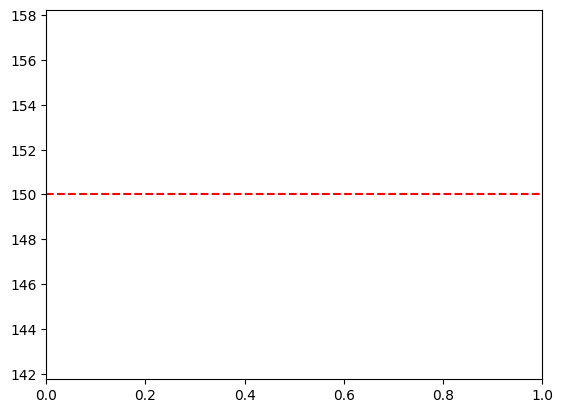

In [ ]:
# prompt: Add a horizontal line to a plot

import matplotlib.pyplot as plt
plt.axhline(y=150, color='r', linestyle='--')

In [ ]:
print(f'T-core = ', T_core[-1])
print(f'rho vapor = ', rhoVaporOven)
print(f'T-core at 20 min = ',T_core[1850])

T-core =  232.661650161995
rho vapor =  0.22536145522892487
T-core at 20 min =  234.6998630645254


The following code block confirms a simulation run without any breaks gives the same result as a simulation performed over two time segments.

Simulation state loaded from drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation_0.58_450F.pkl
Simulation state loaded from drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation_0.58_450F.pkl


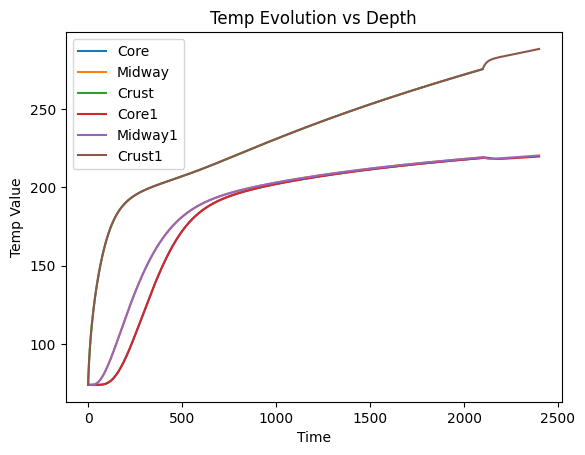

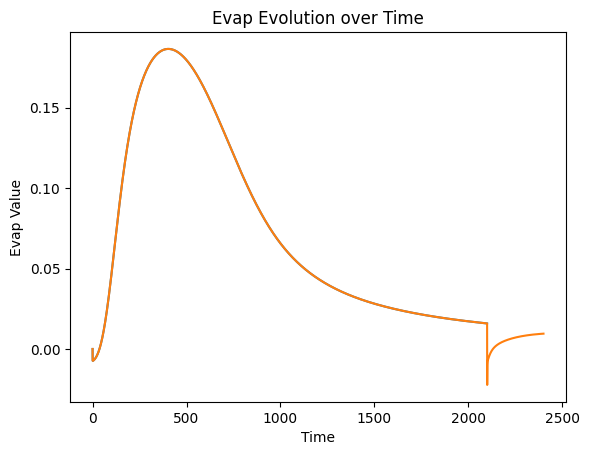

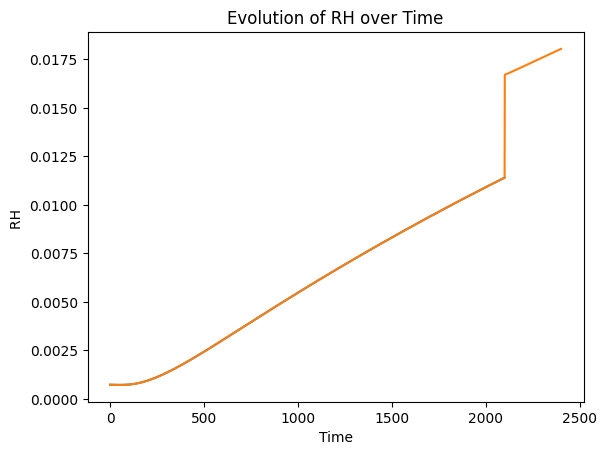

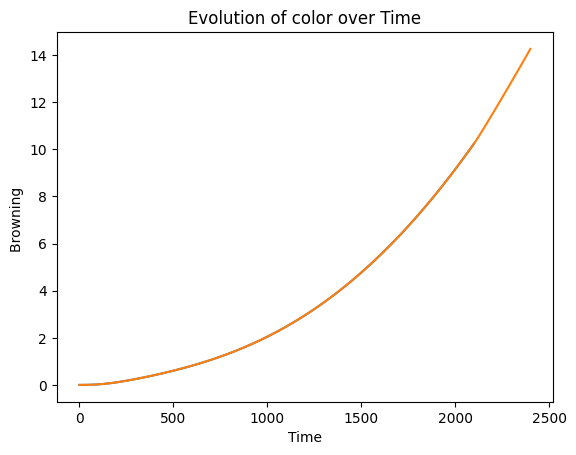

In [ ]:
file_name_read_1 = 'drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation.pkl'
file_name_read = 'drive/My Drive/Colab Notebooks/sourdough/pickles/fipy_simulation_0.58_450F.pkl'
with open(file_name_read, 'rb') as f:
    loaded_simulation_state = pickle.load(f)
    T = loaded_simulation_state['T']
    phi = loaded_simulation_state['phi']
    rhoVsatphi = loaded_simulation_state['rhoVsatphi']
    rhoWsatphi = loaded_simulation_state['rhoWsatphi']
    rhoCsatphi = loaded_simulation_state['rhoCsatphi']
    Wsat = loaded_simulation_state['Wsat']
    rhoCpT = loaded_simulation_state['rhoCpT']
    starting_step = loaded_simulation_state['step'] + 1
    T_oven_t = loaded_simulation_state['T_oven']
    timelapse = loaded_simulation_state['timelapse']
    timepoints_t = loaded_simulation_state['timepoints_t']
    BrowningIndex = loaded_simulation_state['BrowningIndex']
    RHO_t = loaded_simulation_state['RH_oven_t']
    rhoVaporOven_t = loaded_simulation_state['rhoVaporOven_t']
    T_core = loaded_simulation_state['T_core']
    T_mid = loaded_simulation_state['T_mid']
    T_R = loaded_simulation_state['T_R']
    ev = loaded_simulation_state['ev']
    browning = BrowningIndex[-1]
    print(f'Simulation state loaded from {file_name_read}')

with open(file_name_read_1, 'rb') as f:
    loaded_simulation_state_1 = pickle.load(f)
    T1 = loaded_simulation_state_1['T']
    phi1 = loaded_simulation_state_1['phi']
    rhoVsatphi1 = loaded_simulation_state_1['rhoVsatphi']
    rhoWsatphi1 = loaded_simulation_state_1['rhoWsatphi']
    rhoCsatphi1 = loaded_simulation_state_1['rhoCsatphi']
    Wsat1 = loaded_simulation_state_1['Wsat']
    rhoCpT1 = loaded_simulation_state_1['rhoCpT']
    starting_step1 = loaded_simulation_state_1['step'] + 1
    T_oven_t1 = loaded_simulation_state_1['T_oven']
    timelapse1 = loaded_simulation_state_1['timelapse']
    timepoints_t1 = loaded_simulation_state_1['timepoints_t']
    BrowningIndex1 = loaded_simulation_state_1['BrowningIndex']
    RHO_t1 = loaded_simulation_state_1['RH_oven_t']
    rhoVaporOven_t1 = loaded_simulation_state_1['rhoVaporOven_t']
    T_core1 = loaded_simulation_state_1['T_core']
    T_mid1 = loaded_simulation_state_1['T_mid']
    T_R1 = loaded_simulation_state_1['T_R']
    ev1 = loaded_simulation_state_1['ev']
    browning1 = BrowningIndex[-1]

    print(f'Simulation state loaded from {file_name_read}')

plt.plot(timepoints_t, T_core, label='Core')
plt.plot(timepoints_t, T_mid, label='Midway')
plt.plot(timepoints_t, T_R, label='Crust')
plt.plot(timepoints_t1, T_core1, label='Core1')
plt.plot(timepoints_t1, T_mid1, label='Midway1')
plt.plot(timepoints_t1, T_R1, label='Crust1')
plt.xlabel("Time")
plt.ylabel("Temp Value")
plt.title("Temp Evolution vs Depth")
plt.legend()
plt.show()
plt.plot(timepoints_t, ev)
plt.plot(timepoints_t1, ev1)
plt.xlabel("Time")
plt.ylabel("Evap Value")
plt.title("Evap Evolution over Time")
plt.show()
plt.plot(timepoints_t, RHO_t)
plt.plot(timepoints_t1, RHO_t1)
plt.xlabel("Time")
plt.ylabel("RH ")
plt.title("Evolution of RH over Time")
plt.show()
plt.plot(timepoints_t, BrowningIndex)
plt.plot(timepoints_t1, BrowningIndex1)
plt.xlabel("Time")
plt.ylabel("Browning ")
plt.title("Evolution of color over Time")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def Moisture(rhoWsatphi,rhos,phi):
  # moisture fraction of dough on a dry basis
  return rhoWsatphi/(rhos*(1-phi))

def Activity(moisture,temperature):
  act = 1 +((100*moisture)*nx.exp(0.0056*temperature - 5.5))**(-1/0.38)
  return 1.0/act

def Psat_water(temperature):
  # water vapor pressure, Pa
  return 1000*0.6*nx.exp(17.625*(temperature-273)/(temperature-30))

def Fugacity(temperature, rhoWsatphi,rhos,phi):
  #vapor pressure of water in equilibrium with wet dough, Pa
  return Psat_water(temperature)*Activity(Moisture(rhoWsatphi,rhos,phi),temperature)



In [ ]:
# prompt: Create contour plot of Activity as function of Moisture and Temperature

import matplotlib.pyplot as plt
import numpy as np
# Generate a grid of Moisture and Temperature values for plotting
moisture_vals = np.linspace(0.05,0.95,9) # Example range for moisture
temperature_vals = np.linspace(280,480,20) # Example range for temperature (20C to 100C)
M, T = np.meshgrid(moisture_vals, temperature_vals)

# Calculate Activity for each combination of Moisture and Temperature
Activity_vals = Activity(M, T)

# Create the contour plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(M, T*1.8-460, Activity_vals, levels=10, cmap='viridis')
plt.colorbar(contour, label='Water Activity')
plt.xlabel("Moisture (kg Water / kg Dry Solids)")
plt.ylabel("Temperature (F)")
plt.title("Contour Plot of Water Activity")
plt.grid(True)
plt.show()


In [ ]:
# Calculate Activity for each combination of Moisture and Temperature
T=np.linspace(360,400,50)
fugacity_1 = Psat_water(T)*Activity(1.0,T)
fugacity_5 = Psat_water(T)*Activity(0.50,T)
fugacity_4 = Psat_water(T)*Activity(0.40,T)
fugacity_3 = Psat_water(T)*Activity(0.30,T)
fugacity_2 = Psat_water(T)*Activity(0.20,T)

# Create the contour plot
plt.figure(figsize=(8, 6))
plt.xlabel("Temperature F")
plt.ylabel("Vapor Pressure")
plt.title("Fugacity vs Temp")
plt.grid(True)
plt.plot(T*1.8-460.0,fugacity_1, label="Moisture = 100%")
plt.plot(T*1.8-460.0,fugacity_5, label="Moisture =  50%")
plt.plot(T*1.8-460.0,fugacity_4, label="Moisture =  40%")
plt.plot(T*1.8-460.0,fugacity_3, label="Moisture =  30%")
plt.plot(T*1.8-460.0,fugacity_2, label="Moisture =  20%")
plt.legend()
plt.show()